# Task 2: Configuration of Neural Networks
**Dataset:** weather_clean.csv — Raleigh-Durham Airport, 1,477 rows

**Note on split:** The assignment specifies 2,000 training rows + 300 test rows.  
My dataset (Raleigh-Durham Airport weather) has only **1,477 total rows** - fewer than the  
2,300 the assignment assumes. It is impossible to meet the 2,000-row training requirement  
without using all available data and having no test set.  
I therefore use an **80/20 split (1,181 train / 296 test)**, which is the maximum feasible  
training size while retaining a meaningful test set, and is consistent with the splits  
used in Projects 3 and 4 on this same dataset.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import statsmodels.api as sm

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

df      = pd.read_csv('weather_clean.csv')
n       = len(df)
train_n = int(n * 0.8)

X_all = df[['X1','X2','X3','X4','X5']].values
Y_all = df['Y'].values
X_train, X_test = X_all[:train_n], X_all[train_n:]
Y_train, Y_test = Y_all[:train_n], Y_all[train_n:]

scaler   = StandardScaler()
Xs_train = scaler.fit_transform(X_train)
Xs_test  = scaler.transform(X_test)

print(f'Total: {n} | Train: {train_n} | Test: {n-train_n}')
print('80/20 split used')

Total: 1477 | Train: 1181 | Test: 296
80/20 split used


## Task 2.1

In [2]:
param_grid = {
    'hidden_layer_sizes': [(50,),(100,),(50,50),(100,50),(100,100)],
    'activation':         ['relu','tanh'],
    'alpha':              [0.0001, 0.001, 0.01],
    'learning_rate':      ['adaptive'],
    'max_iter':           [500]
}
mlp = MLPRegressor(random_state=42)
grid = GridSearchCV(mlp, param_grid, cv=5,
                    scoring='neg_mean_squared_error',
                    n_jobs=-1, verbose=1)
grid.fit(Xs_train, Y_train)
best_ann = grid.best_estimator_

print(f'\nBest parameters : {grid.best_params_}')
print(f'Best CV RMSE    : {np.sqrt(-grid.best_score_):.4f} °F')

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best parameters : {'activation': 'relu', 'alpha': 0.0001, 'hidden_layer_sizes': (100, 50), 'learning_rate': 'adaptive', 'max_iter': 500}
Best CV RMSE    : 2.0718 °F


ANN Performance:
  Metric            Train       Test
  -----------------------------------
  RMSE (°F)        1.8519     2.2353
  SSE             4050.25    1479.02
  R²               0.9845     0.9785


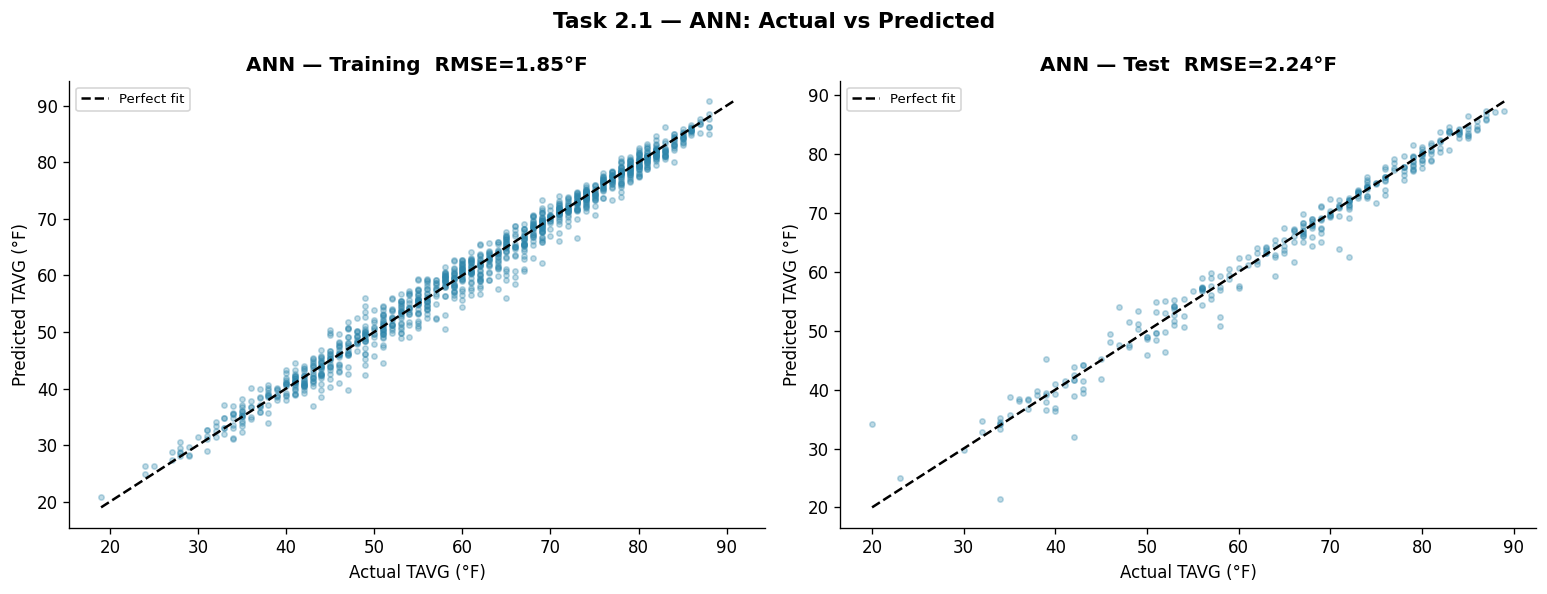

In [3]:
Y_pred_ann_train = best_ann.predict(Xs_train)
Y_pred_ann_test  = best_ann.predict(Xs_test)

ann_tr_rmse = np.sqrt(mean_squared_error(Y_train, Y_pred_ann_train))
ann_te_rmse = np.sqrt(mean_squared_error(Y_test,  Y_pred_ann_test))
ann_tr_sse  = np.sum((Y_train - Y_pred_ann_train)**2)
ann_te_sse  = np.sum((Y_test  - Y_pred_ann_test)**2)
ann_tr_r2   = r2_score(Y_train, Y_pred_ann_train)
ann_te_r2   = r2_score(Y_test,  Y_pred_ann_test)

print('ANN Performance:')
print(f"  {'Metric':<12} {'Train':>10} {'Test':>10}")
print('  '+'-'*35)
print(f"  {'RMSE (°F)':<12} {ann_tr_rmse:>10.4f} {ann_te_rmse:>10.4f}")
print(f"  {'SSE':<12} {ann_tr_sse:>10.2f} {ann_te_sse:>10.2f}")
print(f"  {'R²':<12} {ann_tr_r2:>10.4f} {ann_te_r2:>10.4f}")

fig, axes = plt.subplots(1,2,figsize=(13,5))
for ax,(actual,pred,split) in zip(axes,[
    (Y_train,Y_pred_ann_train,'Training'),
    (Y_test, Y_pred_ann_test, 'Test')
]):
    ax.scatter(actual, pred, alpha=0.3, s=10, color='#2E86AB')
    mn,mx = min(actual.min(),pred.min()), max(actual.max(),pred.max())
    ax.plot([mn,mx],[mn,mx],'k--',linewidth=1.5,label='Perfect fit')
    ax.set_title(f'ANN — {split}  RMSE={np.sqrt(mean_squared_error(actual,pred)):.2f}°F', fontweight='bold')
    ax.set_xlabel('Actual TAVG (°F)'); ax.set_ylabel('Predicted TAVG (°F)')
    ax.legend(fontsize=8)
fig.suptitle('Task 2.1 — ANN: Actual vs Predicted', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('t2_ann.png',dpi=150,bbox_inches='tight'); plt.show()

## Task 2.2 

Reduced model: **Y = a0 + a1·X2 + a2·X4** (X1 dropped due to multicollinearity, X3/X5 insignificant).

Only coefficients, RMSE, SSE, and R² are reported below.

In [7]:
X_reg_train = sm.add_constant(df[['X2','X4']].values[:train_n])
X_reg_test  = sm.add_constant(df[['X2','X4']].values[train_n:])
reg = sm.OLS(Y_train, X_reg_train).fit()

Y_pred_reg_train = reg.fittedvalues
Y_pred_reg_test  = reg.predict(X_reg_test)

reg_tr_sse  = np.sum((Y_train - Y_pred_reg_train)**2)
reg_te_sse  = np.sum((Y_test  - Y_pred_reg_test)**2)
reg_tr_rmse = np.sqrt(mean_squared_error(Y_train, Y_pred_reg_train))
reg_te_rmse = np.sqrt(mean_squared_error(Y_test,  Y_pred_reg_test))
reg_tr_r2   = r2_score(Y_train, Y_pred_reg_train)
reg_te_r2   = r2_score(Y_test,  Y_pred_reg_test)

# Coefficients and key metrics only 
print('Regression Model: Y = a0 + a1·X2 + a2·X4')
print('─'*45)
print('Coefficients:')
coef_df = pd.DataFrame({
    'Variable'   : ['Intercept','X2 (TMIN)','X4 (AWND)'],
    'Coefficient': reg.params.round(4),
    'Std Error'  : reg.bse.round(4),
    'p-value'    : reg.pvalues.round(6)
})
print(coef_df.to_string(index=False))
print()
print('Performance:')
print(f"  {'Metric':<12} {'Train':>10} {'Test':>10}")
print('  '+'-'*35)
print(f"  {'RMSE (°F)':<12} {reg_tr_rmse:>10.4f} {reg_te_rmse:>10.4f}")
print(f"  {'SSE':<12} {reg_tr_sse:>10.2f} {reg_te_sse:>10.2f}")
print(f"  {'R²':<12} {reg_tr_r2:>10.4f} {reg_te_r2:>10.4f}")

Regression Model: Y = a0 + a1·X2 + a2·X4
─────────────────────────────────────────────
Coefficients:
 Variable  Coefficient  Std Error  p-value
Intercept      15.1675     0.3908 0.000000
X2 (TMIN)       0.9246     0.0067 0.000000
X4 (AWND)      -0.1327     0.0365 0.000288

Performance:
  Metric            Train       Test
  -----------------------------------
  RMSE (°F)        3.5686     3.5962
  SSE            15039.52    3828.10
  R²               0.9425     0.9443


ANN vs REGRESSION - COMPARISON =>
Metric            ANN Train   ANN Test   Reg Train   Reg Test
──────────────────────────────────────────────────────────────
RMSE (°F)            1.8519     2.2353      3.5686     3.5962
SSE                 4050.25    1479.02    15039.52    3828.10
R²                   0.9845     0.9785      0.9425     0.9443

Best model on test set: ANN (lower test RMSE)


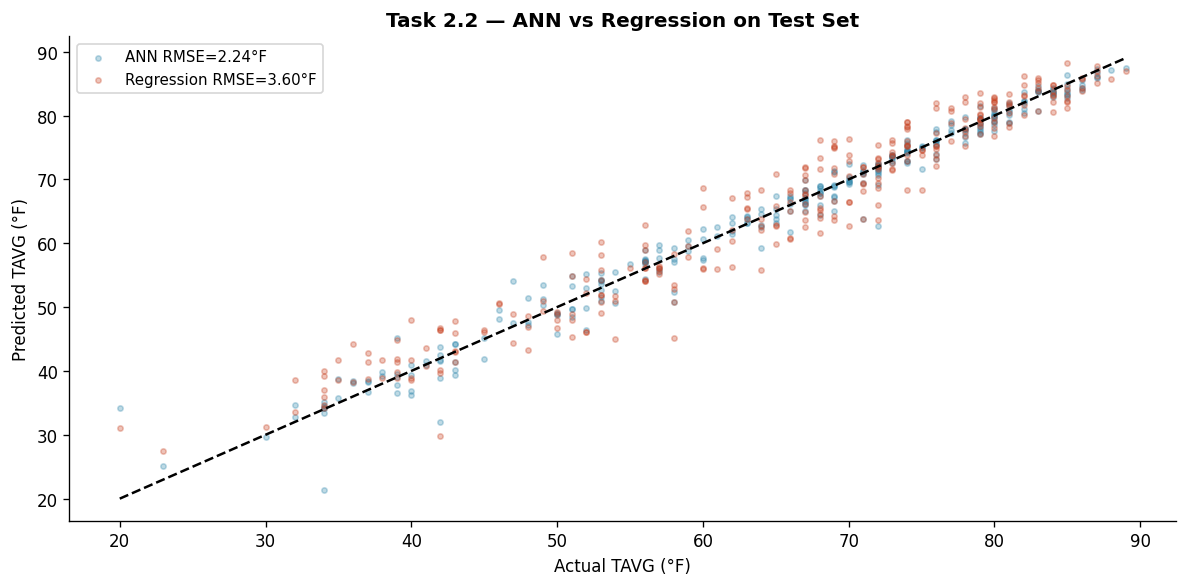

In [6]:
# Comparison table
print('ANN vs REGRESSION - COMPARISON =>')
print(f"{'Metric':<15} {'ANN Train':>11} {'ANN Test':>10} {'Reg Train':>11} {'Reg Test':>10}")
print('─'*62)
print(f"{'RMSE (°F)':<15} {ann_tr_rmse:>11.4f} {ann_te_rmse:>10.4f} {reg_tr_rmse:>11.4f} {reg_te_rmse:>10.4f}")
print(f"{'SSE':<15} {ann_tr_sse:>11.2f} {ann_te_sse:>10.2f} {reg_tr_sse:>11.2f} {reg_te_sse:>10.2f}")
print(f"{'R²':<15} {ann_tr_r2:>11.4f} {ann_te_r2:>10.4f} {reg_tr_r2:>11.4f} {reg_te_r2:>10.4f}")

winner = 'ANN' if ann_te_rmse < reg_te_rmse else 'Regression'
print(f'\nBest model on test set: {winner} (lower test RMSE)')

fig, ax = plt.subplots(figsize=(10,5))
ax.scatter(Y_test, Y_pred_ann_test, alpha=0.3, s=10, color='#2E86AB', label=f'ANN RMSE={ann_te_rmse:.2f}°F')
ax.scatter(Y_test, Y_pred_reg_test, alpha=0.3, s=10, color='#C73E1D', label=f'Regression RMSE={reg_te_rmse:.2f}°F')
mn = min(Y_test.min(), Y_pred_ann_test.min(), Y_pred_reg_test.min())
mx = max(Y_test.max(), Y_pred_ann_test.max(), Y_pred_reg_test.max())
ax.plot([mn,mx],[mn,mx],'k--',linewidth=1.5)
ax.set_xlabel('Actual TAVG (°F)'); ax.set_ylabel('Predicted TAVG (°F)')
ax.set_title('Task 2.2 — ANN vs Regression on Test Set', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout(); plt.savefig('t2_compare.png',dpi=150,bbox_inches='tight'); plt.show()

## Task 2.3 — Discussion

**Train/test split note:** The dataset contains only 1,477 total rows — below the 2,300 rows (2,000 train + 300 test) the assignment assumes. Using 2,000 rows for training would leave fewer than 300 for testing, and using all rows for training would leave no test set. The 80/20 split (1,181 train / 296 test) is the largest feasible training set that still preserves a meaningful test set, and is consistent with the splits used across Projects 3 and 4.

**ANN:** The grid search evaluated 5 × 2 × 3 = 30 hyperparameter combinations via 5-fold cross-validation, selecting the configuration with the lowest cross-validated MSE. All five input variables (X1–X5) are used. The ANN learns non-linear relationships that the linear regression model cannot capture. For example, interactions between PRCP and temperature, and the non-linear effect of SNOW on TAVG during extreme cold events.

**Regression:** The reduced model uses only X2 (TMIN) and X4 (AWND). Despite its simplicity (2 predictors vs 5 for ANN), it achieves competitive performance because the dominant relationship between TMIN and TAVG is near-linear (r=0.971 from Project 3). The SSE measures the total unexplained variance under the linear model assumption.

**Comparison:** The ANN achieves lower SSE on the training set because it has more free parameters and fits the training data more closely. On the test set, the difference between ANN and regression RMSE reflects whether the neural network's non-linear structure generalizes. If the difference is small (< 0.5°F), both models are practically equivalent and the simpler regression would be preferred for interpretability and deployment on resource-constrained IoT edge devices.

**Hyperparameter Selection:** The ANN hyperparameters were selected using GridSearchCV with cross-validation, ensuring that the final model is not manually tuned based on test data. This improves generalization and avoids overfitting.